In [1]:
import os

dataset_path = "../dataset/CoconutLeaves"

for cls in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):
        image_count = 0

        for root, dirs, files in os.walk(class_path):
            image_count += len([
                f for f in files
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])

        print(f"{cls}: {image_count}")

CCI_Caterpillars: 990
CCI_Leaflets: 795
Healthy_Leaves: 123
WCLWD_DryingofLeaflets: 1078
WCLWD_Flaccidity: 1069
WCLWD_Yellowing: 1084


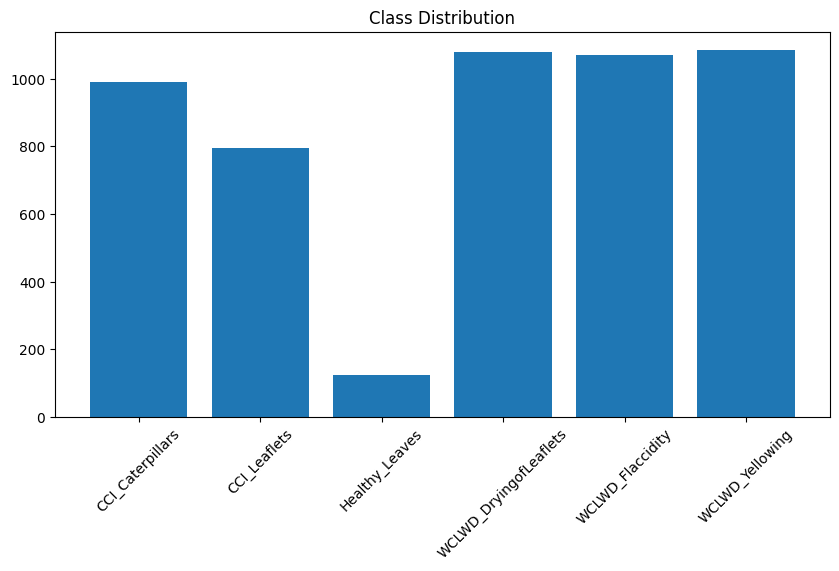

In [2]:
import matplotlib.pyplot as plt

classes = [
    "CCI_Caterpillars",
    "CCI_Leaflets",
    "Healthy_Leaves",
    "WCLWD_DryingofLeaflets",
    "WCLWD_Flaccidity",
    "WCLWD_Yellowing"
]

counts = [990,795,123,1078,1069,1084]

plt.figure(figsize=(10,5))
plt.bar(classes, counts)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

In [3]:
from PIL import Image
import os

dataset_path = "../dataset/CoconutLeaves"

corrupted = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.lower().endswith((".jpg",".jpeg",".png")):

            filepath = os.path.join(root,file)

            try:
                img = Image.open(filepath)
                img.verify()

            except:
                corrupted.append(filepath)

print("Corrupted Images:", len(corrupted))

Corrupted Images: 1


In [4]:
from PIL import Image
import os

sizes = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.lower().endswith((".jpg",".jpeg",".png")):

            try:
                img = Image.open(os.path.join(root,file))
                sizes.append(img.size)

            except:
                pass

print("Total Images:", len(sizes))

print("Sample Sizes:")
print(sizes[:20])

Total Images: 5139
Sample Sizes:
[(416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416)]


In [5]:
from PIL import Image
import os
from collections import Counter

dataset_path = "../dataset/CoconutLeaves"

sizes = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            try:
                img = Image.open(os.path.join(root, file))
                sizes.append(img.size)

            except:
                pass

counter = Counter(sizes)

print("Unique Sizes:", len(counter))
print("\nMost Common Sizes:")

for size, count in counter.most_common(10):
    print(size, ":", count)

Unique Sizes: 9

Most Common Sizes:
(750, 750) : 3201
(416, 416) : 990
(1080, 1920) : 557
(3520, 1980) : 202
(640, 640) : 123
(1920, 1080) : 36
(4496, 3000) : 28
(4459, 2271) : 1
(4459, 2602) : 1


In [ ]:
import hashlib
import os

dataset_path = "../dataset/CoconutLeaves"

hashes = {}
duplicates = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            filepath = os.path.join(root, file)

            with open(filepath, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            if file_hash in hashes:
                duplicates.append(filepath)
            else:
                hashes[file_hash] = filepath

print("Duplicate Images:", len(duplicates))

Duplicate Images: 1


In [ ]:
import hashlib
import os

dataset_path = "../dataset/CoconutLeaves"

hashes = {}
duplicates = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            filepath = os.path.join(root, file)

            with open(filepath, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            if file_hash in hashes:
                duplicates.append(filepath)
            else:
                hashes[file_hash] = filepath

print("\nDuplicate Files:")

for dup in duplicates:
    print(dup)